<h1><center>Laboratorio 7: Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Matías Godoy
- Nombre de alumno 2: Delaney Tello


### **Link de repositorio de GitHub:** [Repositorio](https://github.com/MDS7202-GPT-6/GPT-6)

### Indice

1. [Temas a tratar](#Temas-a-tratar:)
3. [Descripcción del laboratorio](#Descripción-del-laboratorio.)
4. [Desarrollo](#Desarrollo)

## Temas a tratar

- Clasificación usando `XGBoost`.
- Métodos Agnósticos Globales de Interpretabilidad (`Partial Dependence Plot`, `Permutation Feature Importance`)
- Métodos Agnósticos Locales de Interpretabilidad (`Scoped Rules`, `SHAP`)

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.


### Objetivos principales del laboratorio

- Generar un pipeline de clasificación con `XGBoost`.
- Implementar modelos de interpretabilidad para explicar el funcionamiento del modelo de clasificación.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# 1. Problemas Clínicos del Dr. Simi

<p align="center">
  <img src="https://gantz.cl/wp-content/uploads/2020/01/79024136_2718114448239059_7240913062570491904_o.jpg" width="350">
</p>

El reconocido **Dr. Simi**, famoso vendedor de medicamentos en latinoamerica, debido a la creciente prevalencia de enfermedades crónicas, como la diabetes, decidió abrir una clínica especializada en el tratamiento de esta enfermedad en nuestro país.

La clínica del Doctor Simi se convirtió en un lugar donde los pacientes con diabetes podrían recibir atención médica integral. El personal médico estaba compuesto por especialistas en endocrinología, nutrición y enfermería, todos capacitados en el manejo de la diabetes.

Sin embargo él se ha dado cuenta que los tiempos han cambiado y gracias a las tecnologías es posible generar mejores predicciones en la diabetes conociendo el historial médico de las personas. Por esto, el doctor se ha colocado una meta de incluir modelos de machine learning dentro de sus clínicas, para ello le ha solicitado crear un modelo capaz de predecir/clasificar diabetes pero le rogó que el desarrollo del modelo tuviera un especial enfoque en la interpretabilidad de lo que hace su modelo.

Para que usted pueda entrenar el modelo, Dr. Simi le ha entregado un dataset de todos los clientes que fueron detectados con diabetes a lo largo de la historia de la clinica. Con ello, adjunta el historial médico de las personas en forma de datos tabulares para que usted pueda realizar fácilmente la clasificación.


In [4]:
import numpy as np
import pandas as pd

df = pd.read_csv('diabetes_data.csv')
df.head(5)

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Clasificación de pacientes con diabetes (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/QH--g3ZaSbsAAAAC/dr-simi-abrazo.gif" width="400">
</p>

Tareas:
1. En primer lugar, el reconocido doctor le pide entrenar un modelo de `XGBoost` utilizando como target la columna `Diabetes` del dataset `diabetes_data.csv`. Para el entrenamiento, realice los siguientes pasos:
  * Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables. (1 punto)
  * Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. (0.5 puntos)
  * Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`. (1 punto)
  *  Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo. (1 punto)

Comente sus decisiones y los resultados obtenidos con el modelo.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
  * ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

In [5]:
!pip install xgboost

In [6]:
# Inserte su código aquí
# Info general
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   70692 non-null  float64
 1   Sex                   70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   HeartDiseaseorAttack  70692 non-null  float64
 7   PhysActivity          70692 non-null  float64
 8   Fruits                70692 non-null  float64
 9   Veggies               70692 non-null  float64
 10  HvyAlcoholConsump     70692 non-null  float64
 11  GenHlth               70692 non-null  float64
 12  MentHlth              70692 non-null  float64
 13  PhysHlth              70692 non-null  float64
 14  DiffWalk              70692 non-null  float64
 15  Stroke             

In [7]:
print(df.describe())

                Age           Sex      HighChol     CholCheck           BMI  \
count  70692.000000  70692.000000  70692.000000  70692.000000  70692.000000   
mean       8.584055      0.456997      0.525703      0.975259     29.856985   
std        2.852153      0.498151      0.499342      0.155336      7.113954   
min        1.000000      0.000000      0.000000      0.000000     12.000000   
25%        7.000000      0.000000      0.000000      1.000000     25.000000   
50%        9.000000      0.000000      1.000000      1.000000     29.000000   
75%       11.000000      1.000000      1.000000      1.000000     33.000000   
max       13.000000      1.000000      1.000000      1.000000     98.000000   

             Smoker  HeartDiseaseorAttack  PhysActivity        Fruits  \
count  70692.000000          70692.000000  70692.000000  70692.000000   
mean       0.475273              0.147810      0.703036      0.611795   
std        0.499392              0.354914      0.456924      0.487345

In [8]:
print(df['Diabetes'].value_counts(normalize=True))

Diabetes
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

X = df.drop(columns='Diabetes')
y = df['Diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=6, stratify=y
)
num_cols = ['Age', 'BMI', 'GenHlth', 'MentHlth', 'PhysHlth']
passthrough_cols = [c for c in X.columns if c not in num_cols]

In [10]:
import plotly.express as px
for col in num_cols:
    p = px.histogram(
        df, x=col, color='Diabetes', barmode='overlay',
        title=f'Distribución de {col} por Diabetes',
        labels={col: col, 'count': 'Cantidad', 'Diabetes': 'Diabetes'}
    )
    p.show()

In [11]:
preprocessor = make_column_transformer(
    (StandardScaler(), num_cols),
    ('passthrough', passthrough_cols),
    verbose_feature_names_out=False
).set_output(transform='pandas')

xgb = XGBClassifier(
    random_state=6,
    use_label_encoder=False,
    eval_metric='logloss'
)

#Pipeline: preprocesamiento + modelo
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb)
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.77      0.70      0.73     11782
         1.0       0.73      0.79      0.76     11782

    accuracy                           0.75     23564
   macro avg       0.75      0.75      0.75     23564
weighted avg       0.75      0.75      0.75     23564



/Users/matiasgodoy/Universidad/2025-1/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning:

[11:24:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




* ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
Considerandon que se está abordando un caso de clasificación binaria para ámbitos médicos, el modelo no es malo pero tampoco se podría considerar un "buen" predictor de diabetes. El modelo muestra un recall de 0.79 para la clase positiva, es de sus métrias más altas lo cual es beno porque en este tipo de problemas es crucial minimizar los falsos negativos (personas con diabetes clasificadas como no diabéticas). Sin embargo, no es lo suficientemente alto para considerarlo un buen predictor, ya que aún hay un 21% de personas con diabetes que no son detectadas por el modelo. 
* ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
Buscan explicar el desempeño del modelo en términos de su capacidad para clasificar correctamente a los pacientes con y sin diabetes. La precisión mide la proporción de predicciones correctas entre todas las predicciones realizadas (cuantas personas con la etiqueta respectiva son coreectamente clasificadas), el recall mide la proporción de verdaderos positivos entre todos los casos reales positivos, y la F1-score es la media armónica entre precisión y recall, proporcionando un equilibrio entre ambas métricas. En este contexto, el recall es especialmente importante porque queremos minimizar los falsos negativos (personas con diabetes que no son detectadas por el modelo).

* ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)
No, las métricas no dan información sobre la elección de las features. Solo evalúan el desempeño del modelo en términos de clasificación. Para poder asegurar que el modelo haga buena elección de las features, se deben usar técnicas de interpretabilidad y análisis de importancia de características (SHAP por ejemplo).

## 3. Importancia de las features con XGBoost (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/5JAj5_IiagEAAAAd/dr-simi-dr-simi-dance.gif" width="400">
</p>

Tareas:
1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]` (3 puntos)
2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)
3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

<Figure size 1000x600 with 0 Axes>

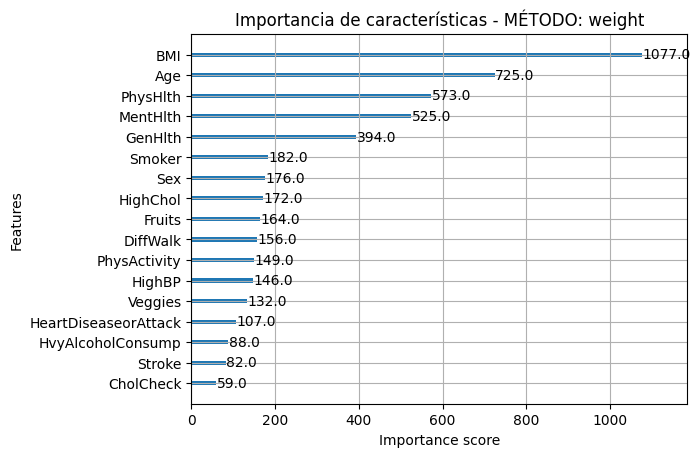

<Figure size 1000x600 with 0 Axes>

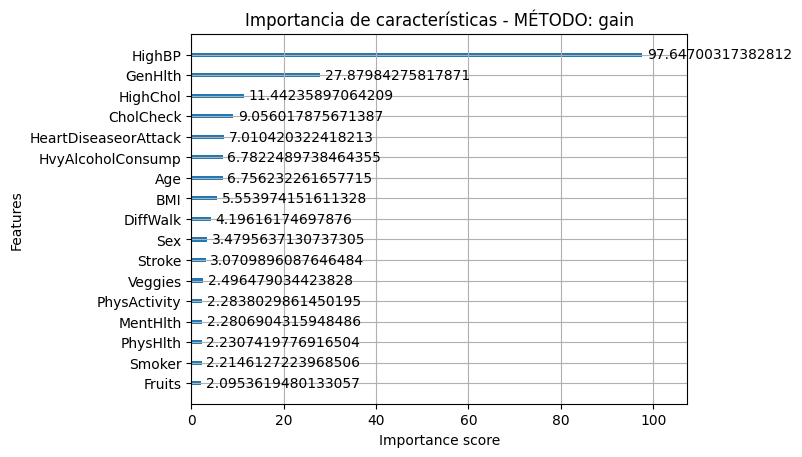

<Figure size 1000x600 with 0 Axes>

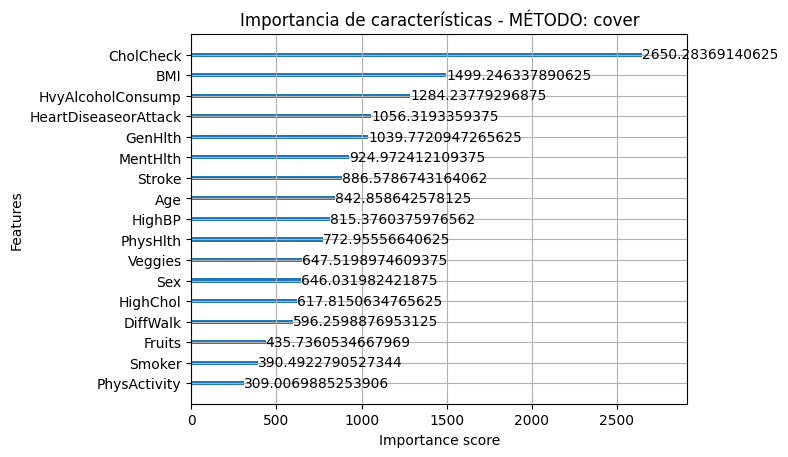

In [12]:
# Inserte su código aquí
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Acceder al modelo dentro del pipeline
xgb_model = pipe.named_steps['model']

# --- Importancia por peso (frecuencia de uso de cada variable en los splits)
plt.figure(figsize=(10,6))
plot_importance(xgb_model, importance_type='weight')
plt.title("Importancia de características - MÉTODO: weight")
plt.show()

# --- Importancia por ganancia (mejora promedio de la precisión al usar una variable)
plt.figure(figsize=(10,6))
plot_importance(xgb_model, importance_type='gain')
plt.title("Importancia de características - MÉTODO: gain")
plt.show()

# --- Importancia por cobertura (número promedio de observaciones afectadas por la variable)
plt.figure(figsize=(10,6))
plot_importance(xgb_model, importance_type='cover')
plt.title("Importancia de características - MÉTODO: cover")
plt.show()

## 4. Métodos Agnósticos Globales (10 puntos)

<p align="center">
  <img src="https://media.tenor.com/JcRHtjVuXN8AAAAC/dr-simi-farmacias-similares.gif" width="400">
</p>

Tareas:
1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
3. Visualice los resultados de este método en un gráfico. (2 puntos)
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

In [13]:
# Inserte su código aquí
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Extraer el modelo y el preprocesador del pipeline
xgb_model = pipe.named_steps['model']
preprocessor = pipe.named_steps['preprocessor']

# Aplicar el preprocesamiento al conjunto de test (manteniendo el orden correcto)
X_test_transformed = preprocessor.transform(X_test)

# Asegurarse de que los nombres de columnas coincidan con el booster
feature_names = xgb_model.get_booster().feature_names

# --- Repetir el proceso 30 veces para estimar estabilidad ---
n_repeats = 30
importances_all = []

for i in range(n_repeats):
    result = permutation_importance(
        xgb_model,
        X_test_transformed,
        y_test,
        n_repeats=1,
        random_state=i,
        scoring='accuracy'
    )
    importances_all.append(result.importances_mean)

# Convertir a DataFrame
importances_df = pd.DataFrame(importances_all, columns=feature_names)

# Promedio y desviación estándar
importances_mean = importances_df.mean()
importances_std = importances_df.std()

/var/folders/8v/t5h1lxj167s84k79jrdfr0380000gn/T/ipykernel_48082/568181813.py:7: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/8v/t5h1lxj167s84k79jrdfr0380000gn/T/ipykernel_48082/568181813.py:8: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



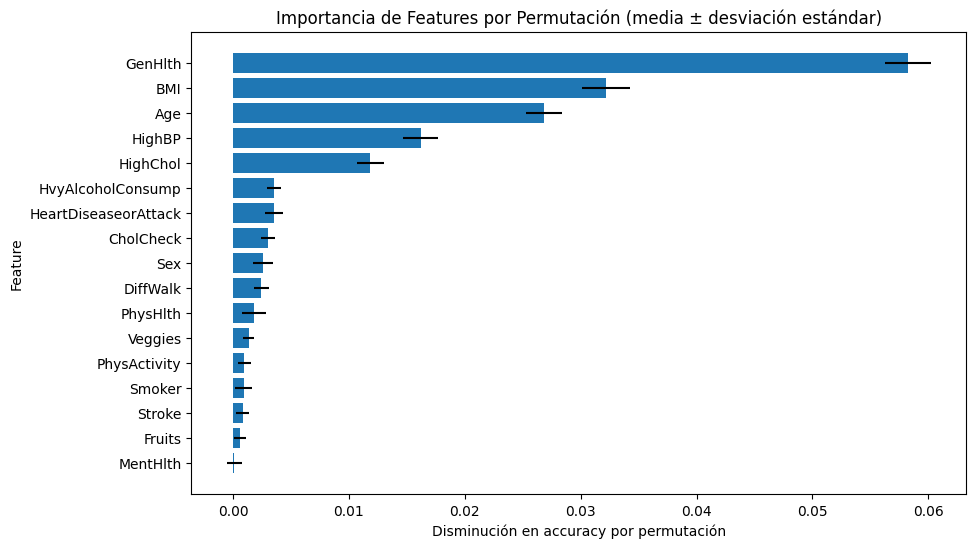

In [14]:
# Ordenar por importancia promedio
sorted_idx = importances_mean.argsort()[::-1]

plt.figure(figsize=(10, 6))
plt.barh(
    np.array(feature_names)[sorted_idx],
    importances_mean[sorted_idx],
    xerr=importances_std[sorted_idx],
    align='center'
)
plt.xlabel("Disminución en accuracy por permutación")
plt.ylabel("Feature")
plt.title("Importancia de Features por Permutación (media ± desviación estándar)")
plt.gca().invert_yaxis()
plt.show()

## 5. Métodos Agnósticos Locales (20 puntos)

<p align="center">
  <img src="https://i.makeagif.com/media/10-24-2024/oMCrLI.gif" width="400">
</p>

### 5.1 Calculando Shap Values (4 puntos)

Tareas:
1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. (2 puntos)
2. ¿Qué representa cada número en su resultado? (1 punto)
3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

In [15]:
!pip install shap

In [16]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")

In [17]:
# Inserte código para calcular shapley values aquí
import shap

# Asegurar preprocesamiento coherente con el modelo
xgb_model = pipe.named_steps['model']
preprocessor = pipe.named_steps['preprocessor']

X_test_transformed = preprocessor.transform(X_test)
feature_names = xgb_model.get_booster().feature_names

# Crear un explainer SHAP compatible con XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Convertir a DataFrame para referencia si se desea inspeccionar
shap_df = pd.DataFrame(shap_values, columns=feature_names)
shap_df.head()

,Age,BMI,GenHlth,MentHlth,PhysHlth,Sex,HighChol,CholCheck,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,DiffWalk,Stroke,HighBP
0,-1.513311,-0.362227,-1.919941,0.066625,-0.130387,0.028823,-0.314679,0.030446,-0.008123,-0.077152,-0.058265,-0.032957,-0.015467,0.004426,-0.072989,-0.019769,-0.734552
1,0.252832,-0.089946,0.112321,0.012479,0.006049,-0.072533,0.258772,0.024470,0.027541,-0.034955,-0.023039,-0.030054,-0.027319,0.046729,0.114690,-0.008046,0.452289
2,0.711473,-0.233928,-0.537188,-0.001876,0.034436,0.121741,0.180570,0.019068,0.000653,-0.024016,-0.012967,-0.031461,-0.003156,0.021228,-0.055784,-0.011556,-0.585446
3,0.134519,-0.360024,0.533826,0.063611,0.010456,-0.049333,0.348676,0.033250,-0.001113,-0.071475,-0.000305,0.004186,-0.049378,0.034381,0.259791,-0.015804,-0.645156
4,-1.412740,-0.734273,-1.759928,0.081905,-0.052842,0.377331,-0.376095,0.030976,0.007837,-0.056190,-0.007468,-0.113071,-0.043568,0.002333,-0.071867,-0.009054,-0.932998


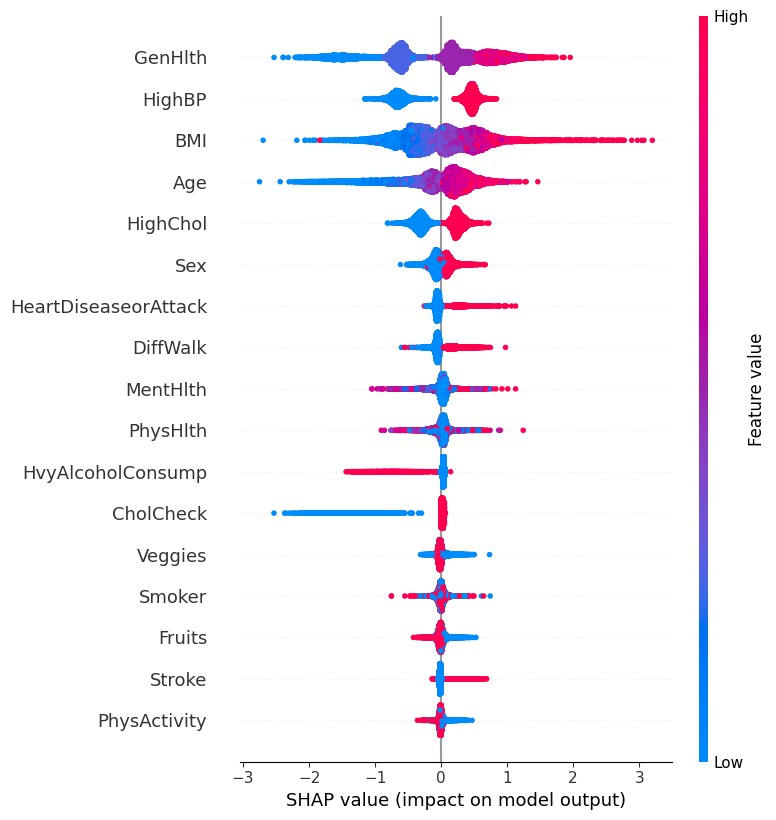

In [18]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

Índices encontrados:
TP=1, TN=0, FP=19, FN=6

🧍 Paciente 1 → Caso: True Positive (TP) ✅
Real=1.0, Predicho=1, Probabilidad=0.734


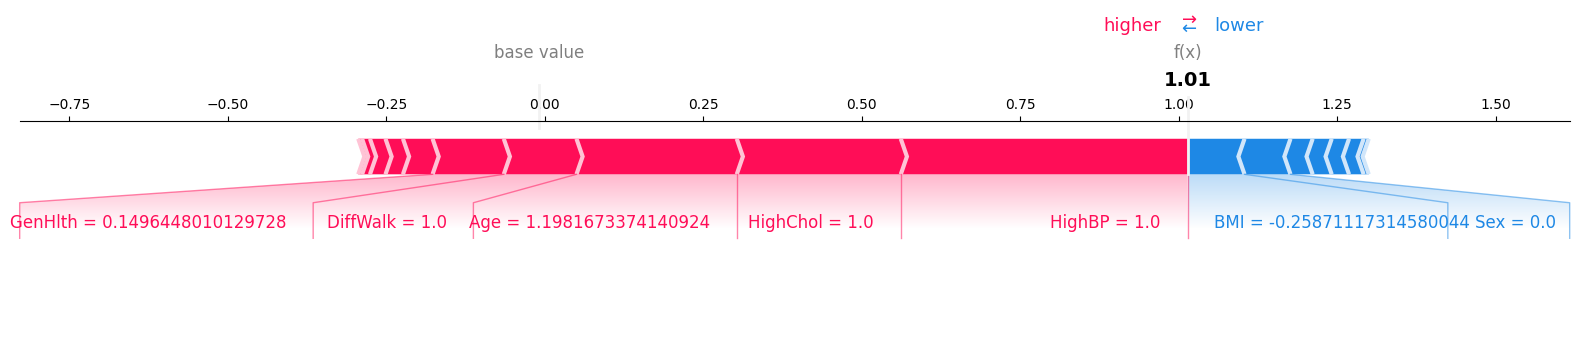


🧍 Paciente 0 → Caso: True Negative (TN) ✅
Real=0.0, Predicho=0, Probabilidad=0.006


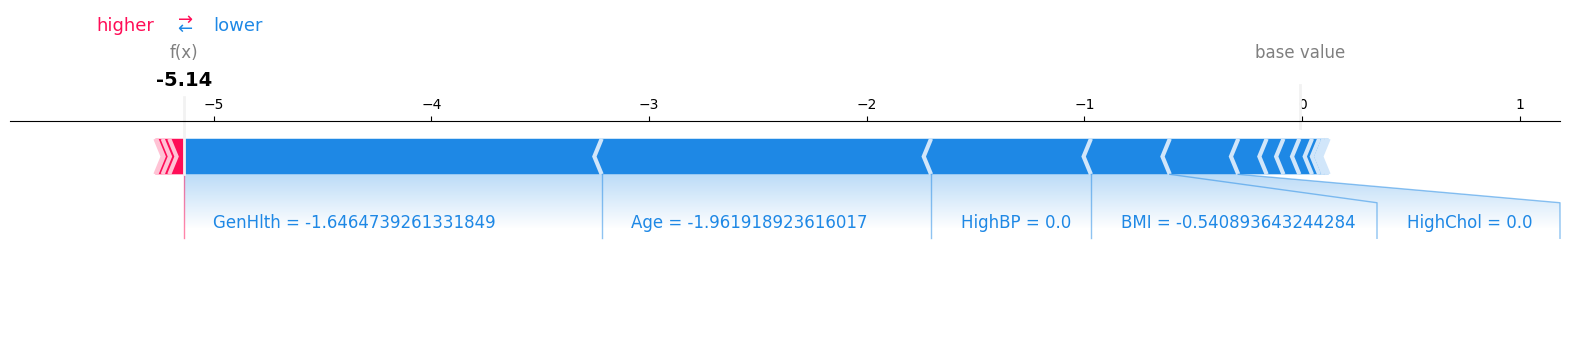


🧍 Paciente 19 → Caso: False Positive (FP) ⚠️
Real=0.0, Predicho=1, Probabilidad=0.787


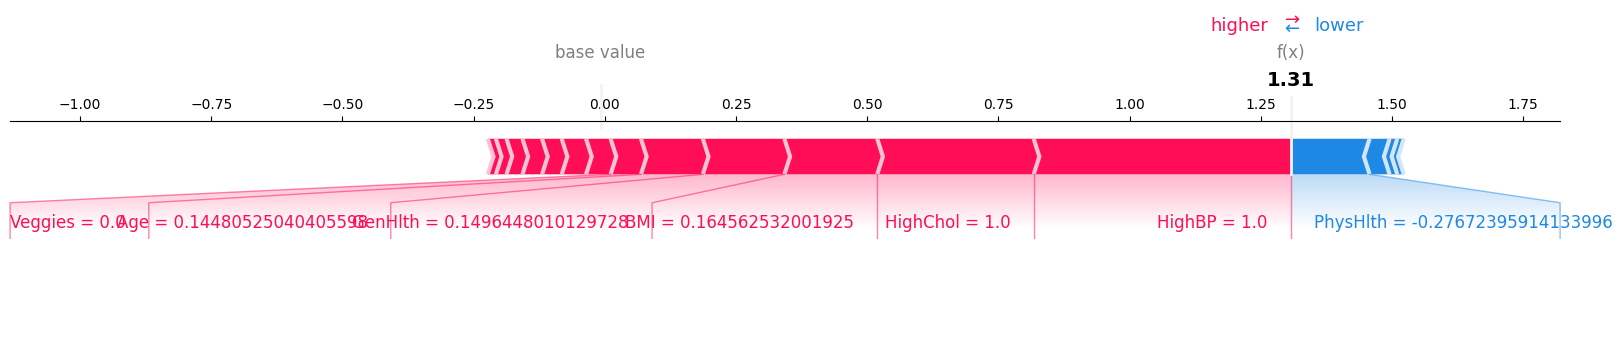


🧍 Paciente 6 → Caso: False Negative (FN) ⚠️
Real=1.0, Predicho=0, Probabilidad=0.326


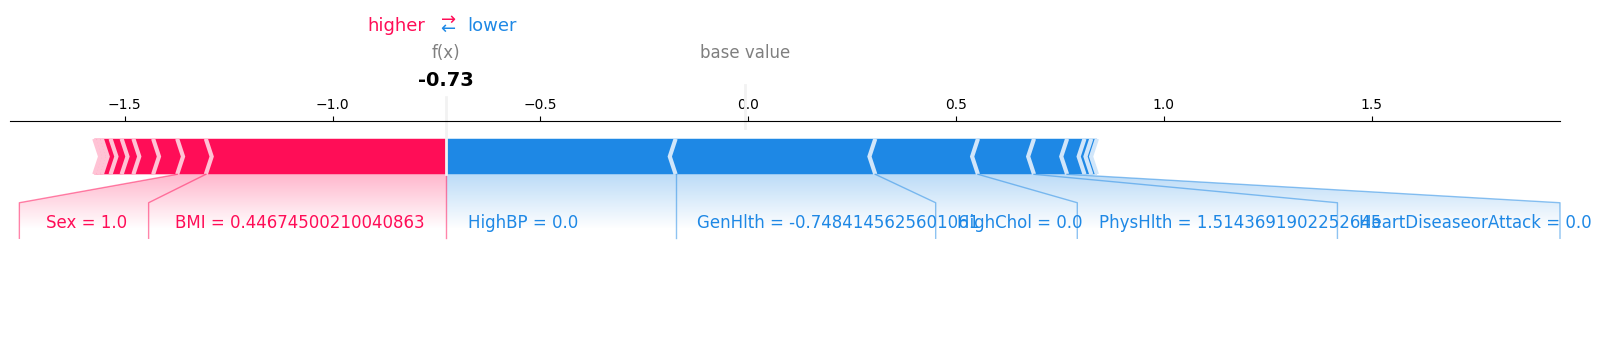

In [19]:
import shap
import numpy as np

# 1️⃣ Obtener predicciones y probabilidades
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

# 2️⃣ Convertir índices
y_test_reset = y_test.reset_index(drop=True)

# 3️⃣ Encontrar índices para cada tipo de caso
idx_TP = np.where((y_test_reset == 1) & (y_pred == 1))[0][0]
idx_TN = np.where((y_test_reset == 0) & (y_pred == 0))[0][0]
idx_FP = np.where((y_test_reset == 0) & (y_pred == 1))[0][0]
idx_FN = np.where((y_test_reset == 1) & (y_pred == 0))[0][0]

print(f"Índices encontrados:\nTP={idx_TP}, TN={idx_TN}, FP={idx_FP}, FN={idx_FN}")

# 4️⃣ Preparar datos y explainer SHAP
xgb_model = pipe.named_steps['model']
preprocessor = pipe.named_steps['preprocessor']

X_test_transformed = preprocessor.transform(X_test)
feature_names = xgb_model.get_booster().feature_names

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# 5️⃣ Función auxiliar para visualizar cada caso
def mostrar_explicacion(idx, tipo):
    real = y_test_reset.iloc[idx]
    pred = y_pred[idx]
    prob = y_proba[idx]
    print(f"\n🧍 Paciente {idx} → Caso: {tipo}")
    print(f"Real={real}, Predicho={pred}, Probabilidad={prob:.3f}")
    shap.force_plot(
        explainer.expected_value,
        shap_values[idx, :],
        X_test_transformed.iloc[idx, :],
        feature_names=feature_names,
        matplotlib=True
    )

# 6️⃣ Visualizar un caso de cada tipo
mostrar_explicacion(idx_TP, "True Positive (TP) ✅")
mostrar_explicacion(idx_TN, "True Negative (TN) ✅")
mostrar_explicacion(idx_FP, "False Positive (FP) ⚠️")
mostrar_explicacion(idx_FN, "False Negative (FN) ⚠️")

### 5.2 Aporte local (4 puntos)

1. Usando los *shap values* calculados, grafique el **aporte local** de las diferentes variables para las instancias **1**, **9** y **150** (1 punto).

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

  - ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

  - ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)


🧍 Paciente 1 — Real=1.0, Predicho=1


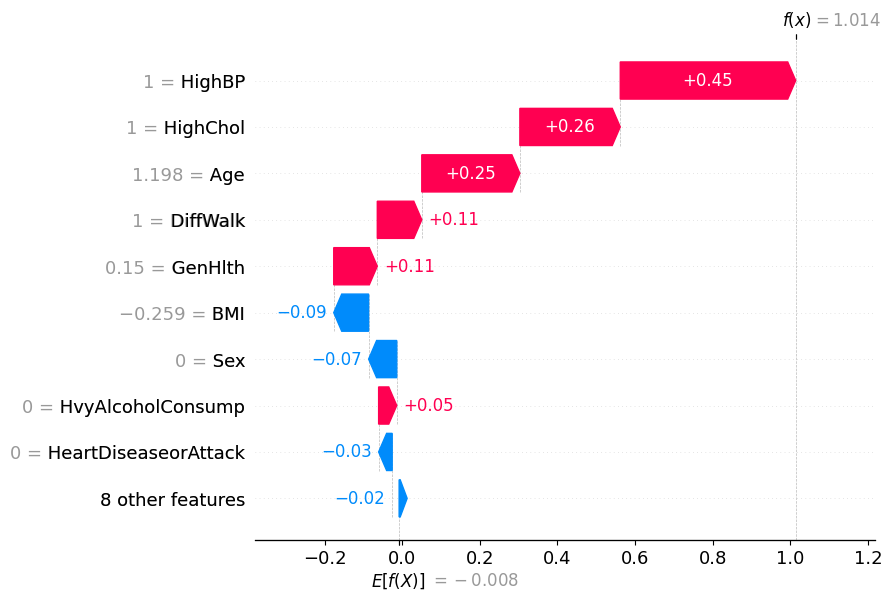


🧍 Paciente 9 — Real=1.0, Predicho=1


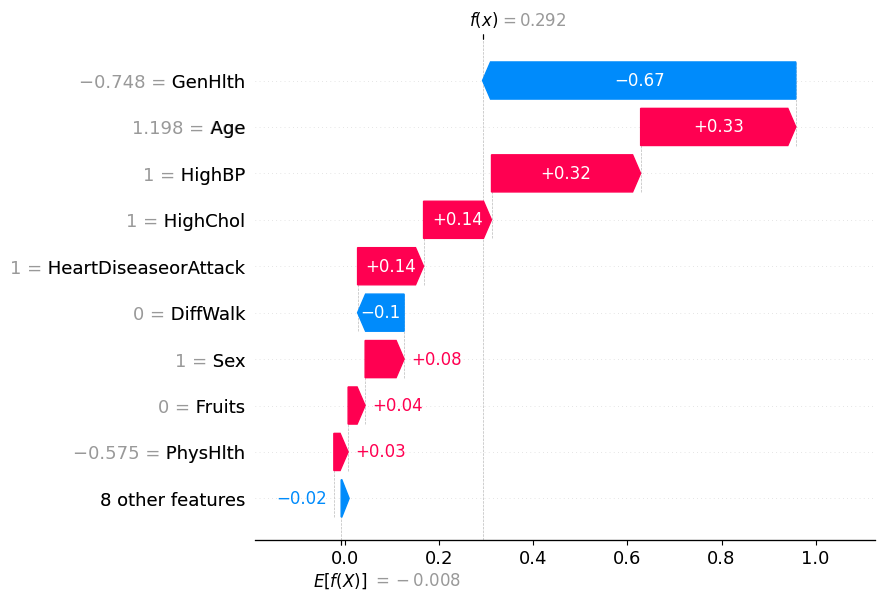


🧍 Paciente 150 — Real=0.0, Predicho=0


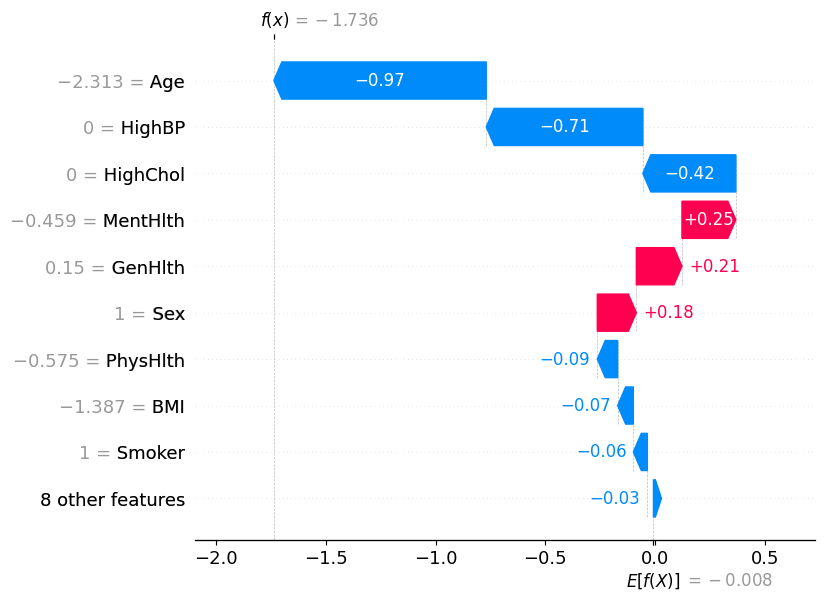

In [20]:
# Inserte código para generar gráficos de aporte local aquí
import shap

# Asegurar coherencia con el pipeline
xgb_model = pipe.named_steps['model']
preprocessor = pipe.named_steps['preprocessor']

X_test_transformed = preprocessor.transform(X_test)
feature_names = xgb_model.get_booster().feature_names

# Calcular valores SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Instancias solicitadas
indices = [1, 9, 150]

for i in indices:
    print(f"\n🧍 Paciente {i} — Real={y_test.reset_index(drop=True).iloc[i]}, Predicho={pipe.predict(X_test.iloc[[i]])[0]}")
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[i],
            base_values=explainer.expected_value,
            data=X_test_transformed.iloc[i],
            feature_names=feature_names
        )
    )

### 5.3 Aporte global (4 puntos)

Genere ahora una visualización donde se grafique el aporte de cada feature a nivel **global** e interprete sus resultados. ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

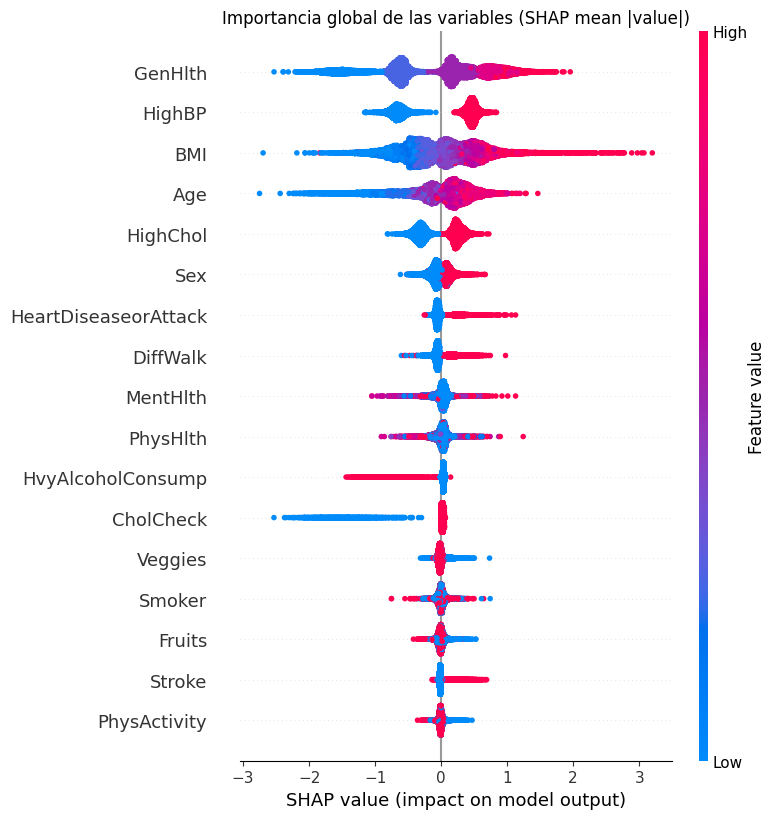

In [21]:
# Inserte código para generar gráficos de aporte global aquí
import shap
import matplotlib.pyplot as plt

# Asegurar coherencia con pipeline
xgb_model = pipe.named_steps['model']
preprocessor = pipe.named_steps['preprocessor']

X_test_transformed = preprocessor.transform(X_test)
feature_names = xgb_model.get_booster().feature_names

# Calcular valores SHAP (si no lo hiciste antes)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# --- Visualización global: importancia media absoluta ---
plt.title("Importancia global de las variables (SHAP mean |value|)")
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

### 5.4 Scatter plot (4 puntos)


Grafique ahora un *scatterplot* entre los *shap values* y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes. ¿Qué puede concluir de sus resultados?

Top 5 features más influyentes: ['GenHlth' 'HighBP' 'BMI' 'Age' 'HighChol']


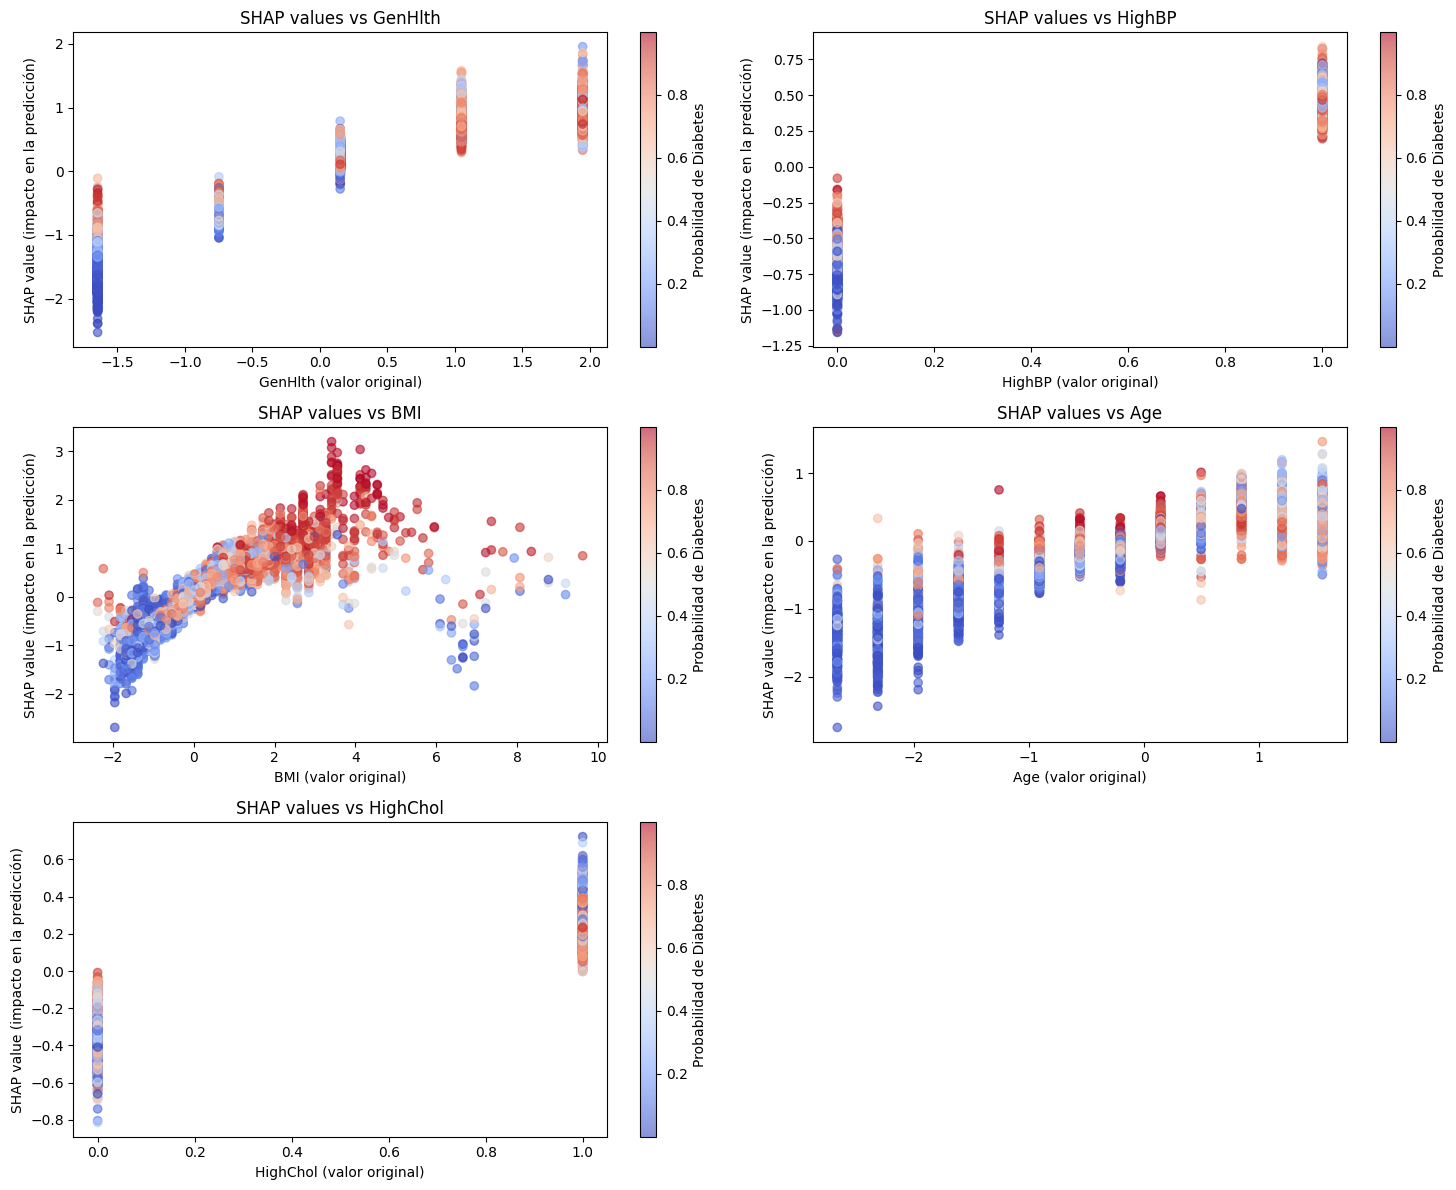

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Asegurar coherencia con pipeline
xgb_model = pipe.named_steps['model']
preprocessor = pipe.named_steps['preprocessor']

# Transformar datos de test y mantener nombres correctos
X_test_transformed = preprocessor.transform(X_test)
feature_names = X_test_transformed.columns  # <-- usamos columnas reales del DataFrame transformado

# Calcular SHAP values con el modelo
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Probabilidades predichas
y_proba = pipe.predict_proba(X_test)[:, 1]

# --- Identificar las 5 variables más influyentes globalmente ---
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top5_idx = np.argsort(mean_abs_shap)[::-1][:5]
top5_features = np.array(feature_names)[top5_idx]

print("Top 5 features más influyentes:", top5_features)

# --- Graficar un scatterplot por cada feature ---
plt.figure(figsize=(15, 12))
for i, feat in enumerate(top5_features, 1):
    plt.subplot(3, 2, i)
    plt.scatter(
        X_test_transformed[feat],
        shap_values[:, top5_idx[i-1]],
        c=y_proba,
        cmap='coolwarm',
        alpha=0.6
    )
    plt.colorbar(label='Probabilidad de Diabetes')
    plt.title(f"SHAP values vs {feat}")
    plt.xlabel(f"{feat} (valor original)")
    plt.ylabel("SHAP value (impacto en la predicción)")
plt.tight_layout()
plt.show()

### 5.5 Partial Dependence Plot (4 puntos)

Finalmente, se le pide generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones. ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

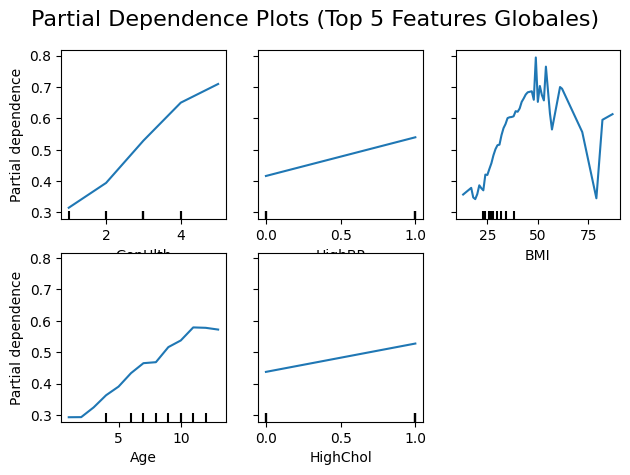

In [23]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import numpy as np

# Submuestra de 1000 observaciones
subsample_idx = np.random.choice(X_test.index, size=1000, replace=False)
X_sub = X_test.loc[subsample_idx]

# Graficar PDP para las 5 features principales
PartialDependenceDisplay.from_estimator(
    pipe,
    X_sub,
    features=top5_features,
    kind='average',
    n_jobs=-1
)
plt.suptitle("Partial Dependence Plots (Top 5 Features Globales)", fontsize=16)
plt.tight_layout()
plt.show()

## 6. Sistema de Reglas! (10 punto)

<p align="center">
  <img src="https://media.baamboozle.com/uploads/images/125978/1638281150_1380186_gif-url.gif" width="400">
</p>

Después de todo el trabajo hecho, Dr. Simi le pide simplificar el funcionamiento de su modelo en un sistema de reglas que le permita explicar a sus clientes las predicciones que genera su modelo.
En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**. Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

`Hint:` Como debe entregar las columnas que entran al clasificador entrenado de su pipeline, le será útil extraer el paso de preprocesamiento y generar dataframes preprocesados para el conjunto `train` y `test`.

In [24]:
!pip install alibi

In [27]:
# Extraer preprocesador y modelo desde el pipeline
preprocessor = pipe.named_steps['preprocessor']
xgb_model = pipe.named_steps['model']

# Transformar datos de entrenamiento y prueba
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Asegurar nombres de columnas
feature_names = preprocessor.get_feature_names_out()

# Convertir a DataFrame para trabajar más cómodo
import pandas as pd
X_train_prep = pd.DataFrame(X_train_prep, columns=feature_names)
X_test_prep = pd.DataFrame(X_test_prep, columns=feature_names)


print(X_train_prep.shape, X_test_prep.shape)

(47128, 17) (23564, 17)


In [29]:
import pandas as pd
from alibi.explainers import AnchorTabular

# ✅ Nueva función predictiva: convierte arrays en DataFrames con nombres
predict_fn = lambda x: pipe.predict(pd.DataFrame(x, columns=feature_names))

# Instanciamos el explicador
explainer = AnchorTabular(predict_fn, feature_names=feature_names)

# Ajustamos el explicador con los datos preprocesados
explainer.fit(X_train_prep.values, disc_perc=(25, 50, 75))


idx = 1000
# explicar predicción idx 1000
# Seleccionar la observación ya preprocesada
instance = X_test_prep.iloc[idx].values.reshape(1, -1)

# Generar explicación
explanation = explainer.explain(instance)

# Mostrar resultados
print("🔹 Reglas (Anchor):", explanation.anchor)
print(f"🎯 Precisión: {explanation.precision:.2f}")
print(f"📈 Cobertura: {explanation.coverage:.2f}")
print(f"Predicción del modelo: {pipe.predict(X_test.iloc[[idx]])[0]}")

idx = 3001
# explicar predicción idx 3001
# Seleccionar la observación ya preprocesada
instance = X_test_prep.iloc[idx].values.reshape(1, -1)

# Generar explicación
explanation = explainer.explain(instance)

# Mostrar resultados
print("🔹 Reglas (Anchor):", explanation.anchor)
print(f"🎯 Precisión: {explanation.precision:.2f}")
print(f"📈 Cobertura: {explanation.coverage:.2f}")
print(f"Predicción del modelo: {pipe.predict(X_test.iloc[[idx]])[0]}")

idx = 5751
# explicar predicción idx 5751
# Seleccionar la observación ya preprocesada
instance = X_test_prep.iloc[idx].values.reshape(1, -1)

# Generar explicación
explanation = explainer.explain(instance)

# Mostrar resultados
print("🔹 Reglas (Anchor):", explanation.anchor)
print(f"🎯 Precisión: {explanation.precision:.2f}")
print(f"📈 Cobertura: {explanation.coverage:.2f}")
print(f"Predicción del modelo: {pipe.predict(X_test.iloc[[idx]])[0]}")




🔹 Reglas (Anchor): ['DiffWalk <= 0.00']
🎯 Precisión: 0.98
📈 Cobertura: 0.75
Predicción del modelo: 1
🔹 Reglas (Anchor): ['DiffWalk <= 0.00']
🎯 Precisión: 0.98
📈 Cobertura: 0.74
Predicción del modelo: 1
🔹 Reglas (Anchor): ['HighBP <= 0.00']
🎯 Precisión: 0.99
📈 Cobertura: 0.44
Predicción del modelo: 0


# Retrospectiva... (10 puntos)

En base a los diferentes métodos que implementa y ha comentado en este laboratorio, comente qué métodos le permiten entregar mejores conclusiones para la tarea de clasificación de diabetes. Por otro lado, ¿qué métodos son más útiles para el problema del doctor Simi, métodos agnosticos locales o globales?

> Fundamente su Respuesta aquí

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>